#### Code comparaison pour chaque version et le MAR

 Le probleme dans ce notebook est que je reouvre les fichiers a chaque fois. Dans ce code tout a ete remodifier suite a la reunion du 12/05, afin d'avoir des cartes en jour par mois et plus en % de SCF et afin de corriger mon >0 en >0.01 dans le code pour avoir une couverture de neige avec MAR

In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import pandas as pd
import os
import sys
import calendar
sys.path.append('/home/mougina/mesnotebooks/utils')
from config import ds_grid, alps, alps_ice, lon, lat, H, get_season

In [2]:
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

In [3]:

ds_topo = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/mougina/GMTED2010_15n015_0050deg.nc').rename(
    {'latitude': 'lat', 'longitude': 'lon'}
)
dsi_topo = ds_topo.sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))

In [4]:
ds_topo_HR = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_topo_alpes_250m.nc")
topo_mondiale_HR = ds_topo_HR['elevation']
lon1, lon2, lat1, lat2 = 4, 17, 43, 48
vrai_topo_alpes_HR = topo_mondiale_HR.sel(
    lon=slice(min(lon1, lon2), max(lon1, lon2)), 
    lat=slice(max(lat1, lat2), min(lat1, lat2)))
facteur_lon = vrai_topo_alpes_HR.shape[1] // ds_grid.LON.shape[1]
facteur_lat = vrai_topo_alpes_HR.shape[0] // ds_grid.LON.shape[0]


sigma_topo_brut = vrai_topo_alpes_HR.coarsen(lon=facteur_lon, lat=facteur_lat, boundary='trim').std()
sigma_topo_aligned = sigma_topo_brut.interp(lon=ds_grid.LON[0, :], lat=ds_grid.LAT[:, 0], method='nearest')
topo_numpy = sigma_topo_aligned.reindex_like(ds_grid, method='nearest').values

In [5]:
file_v2 = '/home/mougina/mes_analyses/Alpine_snow.nc'
ds_v2 = xr.open_dataset(file_v2)

scfg_raw = ds_v2['scfg_interp'].where((ds_v2['scfg_interp'] >= 0) & (ds_v2['scfg_interp'] <= 100))

is_water = ds_v2['mask_water'].fillna(0) == 210
is_ice = ds_v2['mask_ice'].fillna(0) == 215
scfg_final = scfg_raw.where(~is_water & ~is_ice)

##### les differentes versions

**Moyenne pour v4 gap filled par ESA**


In [ ]:


data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_20*.nc"
first_year = 2017
last_year = 2018
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_mfdataset(
    sorted(glob.glob(data_path)), 
    combine='by_coords',
    preprocess=fix_dtype_conflict,
    decode_cf=False  
)
ds = xr.decode_cf(ds_raw)

ds = ds.sel(time=slice(f'{first_year}-01-01', f'{last_year}-12-31'))

scfg = ds['scfg'].where(ds['scfg'] <= 100)

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees
months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):
    m = ax.pcolormesh(
        ds.lon, ds.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=31,
        transform=ccrs.PlateCarree()
    )
    ax.set_title(months[i], fontsize=13)
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False

cbar = fig.colorbar(m, ax=axs, label='nb jours neige / mois',
                    fraction=0.05, aspect=100)
fig.suptitle(f"nombre jour de neige memsuel {first_year}-{last_year}",
             fontsize=15)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/v4_gap_filled/snow_monthly_mean_{first_year}_{last_year}.png', dpi=150)
plt.show()

**Moyenne pour V4 non GF (tjr en pourcentage aussi car inutile pour l'instant)**

In [ ]:

data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_NGF_concat/SCFG_Alps_20*.nc"
first_year = 2017
last_year = 2018
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_mfdataset(
    data_path, 
    combine='by_coords',
    preprocess=fix_dtype_conflict,
    chunks={'time': 1, 'lat': 200, 'lon': 200} # On découpe spatialement aussi !
)

ds = ds_raw.sel(
    time=slice(f'{first_year}-01-01', f'{last_year}-12-31'),
    lat=slice(lat1, lat2), 
    lon=slice(lon1, lon2)
)

scfg = ds['scfg'].where(ds['scfg'] <= 100).astype('float32')
seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees


monthly_means_list = []
months_indices = range(1, 13)

for m in months_indices:
    print(f"Calcul pour le mois {m}...")

    mean_m = scfg.sel(time=scfg['time.month'] == m).mean(dim='time').compute()

    mean_m = mean_m.expand_dims(month=[m])
    monthly_means_list.append(mean_m)



months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 7),
                        subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):
    m = ax.pcolormesh(
        monthly_days_avg.lon, monthly_days_avg.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=31,
        transform=ccrs.PlateCarree(),
        shading='auto'
    )
    ax.contour(
        ds_topo.lon, ds_topo.lat, ds_topo.elevation,
        levels=[1000],
        colors='black', 
        linewidths=0.7,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    ax.set_title(months[i], fontsize=13)
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False

cbar = fig.colorbar(m, ax=axs, label='nb jour neige par mois(%)',
                    fraction=0.05, aspect=100)
fig.suptitle(f"jour neige mensuel SCFG (v4.0) {first_year}-{last_year}", fontsize=15)

output_name = f'snow_monthly_mean_v4NGF_{first_year}_{last_year}.png'
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/v4_brut/{output_name}', dpi=150)
plt.show()

In [ ]:
sur la carte ci-dessus on retrouve peu de jour par mois avec de la neige et cest normal car sur 31 jours on a deja pas du tout 31 donnees, cest pareil par ailleurs pour la v2 non gap-filled

**Moyenne pour v2 gap fille par IGE**

In [ ]:

save_data = '/home/mougina/mes_analyses_neige'
data_file = save_data + '/Alpine_snow.nc'

first_year = 2017
last_year = 2018
lat1, lat2, lon1, lon2 = 43, 48, 5, 17
def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_dataset(
    data_file, 
    decode_cf=False, 
    chunks={'time': 100, 'lat': 100, 'lon': 100} 
)

ds_raw = fix_dtype_conflict(ds_raw)
ds = xr.decode_cf(ds_raw)

scfg = ds['scfg_interp'].sel(time=slice(str(first_year), str(last_year)))

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees


months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 7),
                        subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):

    m = ax.pcolormesh(
        ds.lon, ds.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=31,
        transform=ccrs.PlateCarree()
    )
    ax.set_title(months[i], fontsize=13)
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False

cbar = fig.colorbar(m, ax=axs, label='nombre jours de neige / mois',
                    fraction=0.05, aspect=100)
fig.suptitle(f"nombre jour neige mensuel (SNOW-CCI)  avec v2 GF{first_year}-{last_year}",
             fontsize=15, fontweight='bold')

plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/v2_gap_filled/snow_cci_monthly_mean_{first_year}_{last_year}.png', dpi=150)
plt.show()

print(ds.time.max().values)
print(ds.time.tail(5).values)

**moyenne non gap fille avec v2 et surtout que 2018 car probleme sur 2017 pour l'instant**

In [ ]:
data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_20*.nc"
first_year = 2018
last_year = 2018
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

files = sorted(glob.glob(data_path))
if not files:
    raise FileNotFoundError(f"Aucun fichier trouvé dans {data_path}")
    
ds_ref = xr.open_dataset(files[0])
ref_lat = ds_ref.lat
ref_lon = ds_ref.lon

def preprocess_modis_final(ds):  
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    
    ds = ds.reindex(lat=ref_lat, lon=ref_lon, method='nearest')
    return ds


ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',
    preprocess=preprocess_modis_final,
    coords='minimal',
    compat='override',
    join='override',
    decode_cf=True
)

ds = ds.sel(time=slice(f'{first_year}-01-01', f'{last_year}-12-31'))

scfg = ds['scfg'].where((ds['scfg'] >= 0) & (ds['scfg'] <= 100))

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees

if (monthly_days_avg.lon > 180).any():
    monthly_days_avg = monthly_days_avg.assign_coords(lon=(((monthly_days_avg.lon + 180) % 360) - 180))
    monthly_days_avg = monthly_days_avg.sortby('lon')

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(20, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})

lons, lats = monthly_days_avg.lon, monthly_days_avg.lat

for i, ax in enumerate(axs.flat):
    try:
        data_month = monthly_days_avg.sel(month=i+1)
        
        m = ax.pcolormesh(
            lons, lats, data_month,
            cmap='Blues', vmin=0, vmax=31,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )
    except Exception:
        ax.text(0.5, 0.5, "Pas de données", transform=ax.transAxes, ha='center')

    ax.set_title(months[i], fontsize=12, fontweight='bold')
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3) # Pour voir où sont les trous
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False

cbar = fig.colorbar(m, ax=axs, label='nb jours neige / mois',
                    fraction=0.05, aspect=100)

fig.suptitle(f"nombre de jours de neuge mensuel SCFG {first_year} (Alpes) v2 NGF", fontsize=16, y=0.96)

output = f'/home/mougina/mes_analyses_neige/moyenne_test/v2_brut/snow_monthly_mean_{first_year}.png'
plt.savefig(output, dpi=200, bbox_inches='tight')
plt.show()

#### code meme chose mais zoomer sur massif du Belledonne


v4 GP

In [ ]:


data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_20*.nc"
first_year = 2017
last_year = 2018
lieu ='belledonne'
lat1, lat2, lon1, lon2 =  45, 45.3, 5.8, 6.3  #la cest Belledonne pour verifier 
vmax = 31
def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_mfdataset(
    sorted(glob.glob(data_path)), 
    combine='by_coords',
    preprocess=fix_dtype_conflict,
    decode_cf=False  
)
ds = xr.decode_cf(ds_raw)

ds = ds.sel(time=slice(f'{first_year}-01-01', f'{last_year}-12-31'))

scfg = ds['scfg'].where(ds['scfg'] <= 100)

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):
    m = ax.pcolormesh(
        ds.lon, ds.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax.set_title(months[i], fontsize=13)
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False
    cs = ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[500,1000,1500,2000,2500,3000,3500],colors='grey',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=2)
    ax.clabel(cs, inline=True, fontsize=7, fmt='%1.0f',  colors='grey')
cbar = fig.colorbar(m, ax=axs, label='nombre jours de neige / mois ',
                    fraction=0.05, aspect=100)
fig.suptitle(f" Nombre jours de neige avec Gap-Filled V4 {last_year}\n(Échelle 0-{vmax}jours) {lieu}")
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/v4_gap_filled/snow_monthly_mean_{first_year}_{last_year}{lieu}.png', dpi=150)
plt.show()

v2 GP

In [ ]:

save_data = '/home/mougina/mes_analyses_neige'
data_file = save_data + '/Alpine_snow.nc'

first_year = 2017
last_year = 2018
# ZOOM Belledonne
lon_min, lon_max =5.8, 6.3                               #6.5, 7.2 mt blanc
lat_min, lat_max =45.0, 45.3                             #45.7, 46.1

def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_dataset(
    data_file, 
    decode_cf=False, 
    chunks={'time': 50, 'lat': 100, 'lon': 100} 
)

ds_zoom = ds_raw.sel(
    lat=slice(lat_min, lat_max), 
    lon=slice(lon_min, lon_max)
)

ds_zoom = fix_dtype_conflict(ds_zoom)
ds = xr.decode_cf(ds_zoom)
scfg = ds['scfg_interp'].sel(time=slice(str(first_year), str(last_year)))

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees


months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):
    m = ax.pcolormesh(
        ds.lon, ds.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=31, 
        transform=ccrs.PlateCarree()
    )
    
    ax.set_title(months[i], fontsize=13, fontweight='bold')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    ax.coastlines(resolution='10m', color='black', linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False
    cs = ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[500,1000,1500,2000,2500,3000,3500],colors='grey',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=2)
    ax.clabel(cs, inline=True, fontsize=7, fmt='%1.0f',  colors='grey')
cbar = fig.colorbar(m, ax=axs, label='nombre jours de neige / mois',
                    fraction=0.03, aspect=50, pad=0.05)

fig.suptitle(f" nombre jour neige mensuel  Gap-Filled V2 {last_year}\n(Échelle 0-31jours ) au lautaret")
output_path = f'{save_data}/moyenne_test/v2_gap_filled/zoom_MB_monthly_mean_{last_year}lautaret.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')


V2 NGF 

In [ ]:
data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_20*.nc"
first_year = 2018
last_year = 2018
lat1, lat2, lon1, lon2 =45, 45.3, 5.8, 6.3

files = sorted(glob.glob(data_path))
if not files:
    raise FileNotFoundError(f"Aucun fichier trouvé dans {data_path}")
    
ds_ref = xr.open_dataset(files[0])
ref_lat = ds_ref.lat
ref_lon = ds_ref.lon

def preprocess_modis_final(ds):  
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    
    ds = ds.reindex(lat=ref_lat, lon=ref_lon, method='nearest')
    return ds


ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='time',
    preprocess=preprocess_modis_final,
    coords='minimal',
    compat='override',
    join='override',
    decode_cf=True
)

ds = ds.sel(time=slice(f'{first_year}-01-01', f'{last_year}-12-31'))

scfg = ds['scfg'].where((ds['scfg'] >= 0) & (ds['scfg'] <= 100))

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees

if (monthly_days_avg.lon > 180).any():
    monthly_days_avg = monthly_days_avg.assign_coords(lon=(((monthly_days_avg.lon + 180) % 360) - 180))
    monthly_days_avg = monthly_days_avg.sortby('lon')

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(20, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})

lons, lats = monthly_days_avg.lon, monthly_days_avg.lat

for i, ax in enumerate(axs.flat):
    try:
        data_month = monthly_days_avg.sel(month=i+1)
        
        m = ax.pcolormesh(
            lons, lats, data_month,
            cmap='Blues', vmin=0, vmax=31,
            transform=ccrs.PlateCarree(),
            shading='auto'
        )
    except Exception:
        ax.text(0.5, 0.5, "Pas de données", transform=ax.transAxes, ha='center')

    ax.set_title(months[i], fontsize=12, fontweight='bold')
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3) # Pour voir où sont les trous
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False

cbar = fig.colorbar(m, ax=axs, label='nb jours neige / mois',
                    fraction=0.05, aspect=100)

fig.suptitle(f"nombre de jours de neuge mensuel SCFG {first_year} (Alpes) v2 NGF", fontsize=16, y=0.96)

output = f'/home/mougina/mes_analyses_neige/moyenne_test/v2_brut/snow_monthly_mean_{first_year}.png'
plt.savefig(output, dpi=200, bbox_inches='tight')
plt.show()

## Maintenant place aux evolution temporelle a des endroits precis 

**pour la v4 gap fille**

In [ ]:

data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_2018*.nc"
files = sorted(glob.glob(data_path))

ds_raw = xr.open_dataset(files[0], decode_cf=False)
lieu = "col du lautaret"
for v in ds_raw.variables:
    if 'dtype' in ds_raw[v].attrs:
        del ds_raw[v].attrs['dtype']

ds = xr.decode_cf(ds_raw)

test_point = ds['scfg'].sel(lon=6.4, lat=45.0, method="nearest").squeeze()   #### localisation


vrai_neige = (test_point > 50) & (test_point <= 100)
mesure = (test_point > 0) & (test_point <= 100)
jours_par_mois = vrai_neige.groupby('time.month').sum(dim='time')
jour_mesure = mesure.groupby('time.month').sum(dim='time')
print(jours_par_mois.values)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 13), jours_par_mois.values, 'o', color='royalblue', linewidth=2, label = "jour enneige")
plt.plot(range(1, 13), jour_mesure.values, '_', color='red', linewidth=2, label = "jour mesure")
plt.title(f"Jours de neige par mois - 2018 - {lieu} v2 NGF")
plt.xticks(range(1, 13), ['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylim(0, 35)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()






**pour la v2 gap fille**

In [ ]:

data_path = '/home/mougina/mes_analyses/Alpine_snow.nc'
var_name = 'scfg_interp'  
target_year = 2017
lieu = "col du lautaret"
ds_raw = xr.open_dataset(data_path, decode_cf=False)
for v in ds_raw.variables:
    if 'dtype' in ds_raw[v].attrs:
        del ds_raw[v].attrs['dtype']
ds = xr.decode_cf(ds_raw)

ds_year = ds.sel(time=str(target_year))
test_point = ds_year[var_name].sel(lon=6.4, lat=45.0, method="nearest").squeeze()
vrai_neige = (test_point > 50) & (test_point <= 100)
mesure = (test_point > 0) & (test_point <= 100)
jours_par_mois = vrai_neige.groupby('time.month').sum(dim='time')
jour_mesure = mesure.groupby('time.month').sum(dim='time')
print("Nombre de jours de neige :")
print(jours_par_mois.values)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 13), jours_par_mois.values, 'o', color='royalblue', linewidth=2, label = "jour enneige")
plt.plot(range(1, 13), jour_mesure.values, '_', color='red', linewidth=2, label = "jour mesure")
plt.title(f"Jours de neige par mois - 2018 - {lieu} v2 NGF")
plt.xticks(range(1, 13), ['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylim(0, 35)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

**pour la v2 non gap fille**

In [ ]:

data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_2018.nc"
files = sorted(glob.glob(data_path))
ds_raw = xr.open_dataset(files[0], decode_cf=False)

for v in ds_raw.variables:
    if 'dtype' in ds_raw[v].attrs:
        del ds_raw[v].attrs['dtype']
ds = xr.decode_cf(ds_raw)

test_point = ds['scfg'].sel(lon=6.4, lat=45.0, method="nearest").squeeze()

vrai_neige = (test_point > 50) & (test_point <= 100)
mesure = (test_point > 0) & (test_point <= 100)
jours_par_mois = vrai_neige.groupby('time.month').sum(dim='time')
jour_mesure = mesure.groupby('time.month').sum(dim='time')
print("Nombre de jours de neige :")
print(jours_par_mois.values)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 13), jours_par_mois.values, 'o', color='royalblue', linewidth=2, label = "jour enneige")
plt.plot(range(1, 13), jour_mesure.values, '_', color='red', linewidth=2, label = "jour mesure")
plt.title(f"Jours de neige par mois - 2018 - {lieu} v2 NGF")
plt.xticks(range(1, 13), ['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylim(0, 35)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()



**v4 non gap fille**

In [ ]:

path_recursive = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_NGF_global/2018/**/*.nc"
lon_site, lat_site = 6.4, 45.0
lieu = "Col du Lautaret"

# 1. Ouverture optimisée (une seule fois)
ds = xr.open_mfdataset(path_recursive, 
                       combine='by_coords', 
                       decode_cf=True,      
                       parallel=True)

# 2. Extraction du point
test_point = ds['scfg'].sel(lon=lon_site, lat=lat_site, method="nearest")

# 3. Calculs (On utilise bien les noms définis ici)
vrai_neige = ((test_point > 50) & (test_point <= 100)).groupby('time.month').sum(dim='time')
jour_mesure = ((test_point >= 0) & (test_point <= 100)).groupby('time.month').sum(dim='time')

# 4. Affichage (Correction du nom ici)
print("Nombre de jours de neige par mois :")
print(vrai_neige.values) 

# 5. Plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 13), vrai_neige.values, 'o', color='royalblue', label="Jour enneigé")
plt.plot(range(1, 13), jour_mesure.values, '_', markersize=15, markeredgewidth=2, color='red', label="Jours mesurés")

plt.title(f"Données multi-dossiers - {lieu} (2018)")
plt.xticks(range(1, 13), ['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylim(-1, 35)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.show()

**tout sauf v4 non gap fille**

In [ ]:

# --- CONFIGURATION ---
lon_site, lat_site = 
lieu = "Col du Lautaret"
year = "2018"
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values

# 2. On crée le label qui sera utilisé dans le titre
lieu_titre = f"{lieu} ({int(alt_site)}m)"

# L'ordre que tu as demandé : V4 Alps -> V2 NGF (global) -> V2 Gap-filled (Alpine_snow)
paths = [
    ("V4 Gap-filled (Alps)", "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_2018.nc"),
    ("V2 Non Gap-filled", "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_2018.nc"),
    ("V2 Gap-filled ", "/home/mougina/mes_analyses_neige/Alpine_snow.nc")
]

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
months = ['J','F','M','A','M','J','J','A','S','O','N','D']

for i, (label, path) in enumerate(paths):
    # 1. Chargement
    ds_raw = xr.open_dataset(path, decode_cf=False)
    for v in ds_raw.variables:
        if 'dtype' in ds_raw[v].attrs: del ds_raw[v].attrs['dtype']
    ds = xr.decode_cf(ds_raw)
    
    # 2. Logique de sélection (V2 Gap-filled est le seul multi-annuel avec scfg_interp)
    is_v2_gf = "V2 Gap-filled " in label
    var_name = 'scfg_interp' if is_v2_gf else 'scfg'
    temp_ds = ds.sel(time=year) if is_v2_gf else ds
    
    # 3. Extraction du point
    test_point = temp_ds[var_name].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
    
    # 4. Calculs
    vrai_neige = ((test_point > 50) & (test_point <= 100)).groupby('time.month').sum()
    jour_mesure = ((test_point >= 0) & (test_point <= 100)).groupby('time.month').sum()
    
    # 5. Plot
    ax = axs[i]
    ax.plot(range(1, 13), vrai_neige.values, 'o', color='royalblue', label="Jour enneigé (>50%)")
    ax.plot(range(1, 13), jour_mesure.values, '_', markersize=12, markeredgewidth=2, color='red', label="Jours avec données valides")
    
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.set_ylim(-1, 35)
    ax.grid(axis='y', alpha=0.3)
    if i == 0: ax.set_ylabel("Nombre de jours", fontsize=12)

# --- LÉGENDE UNIQUE EN DEHORS (EN BAS) ---
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)

plt.suptitle(f"Comparaison des types de fichiers - {lieu} ({year})", fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15) # Ajustement pour laisser la place à la légende en bas


plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu} en 2018.png', dpi=150)
plt.show()

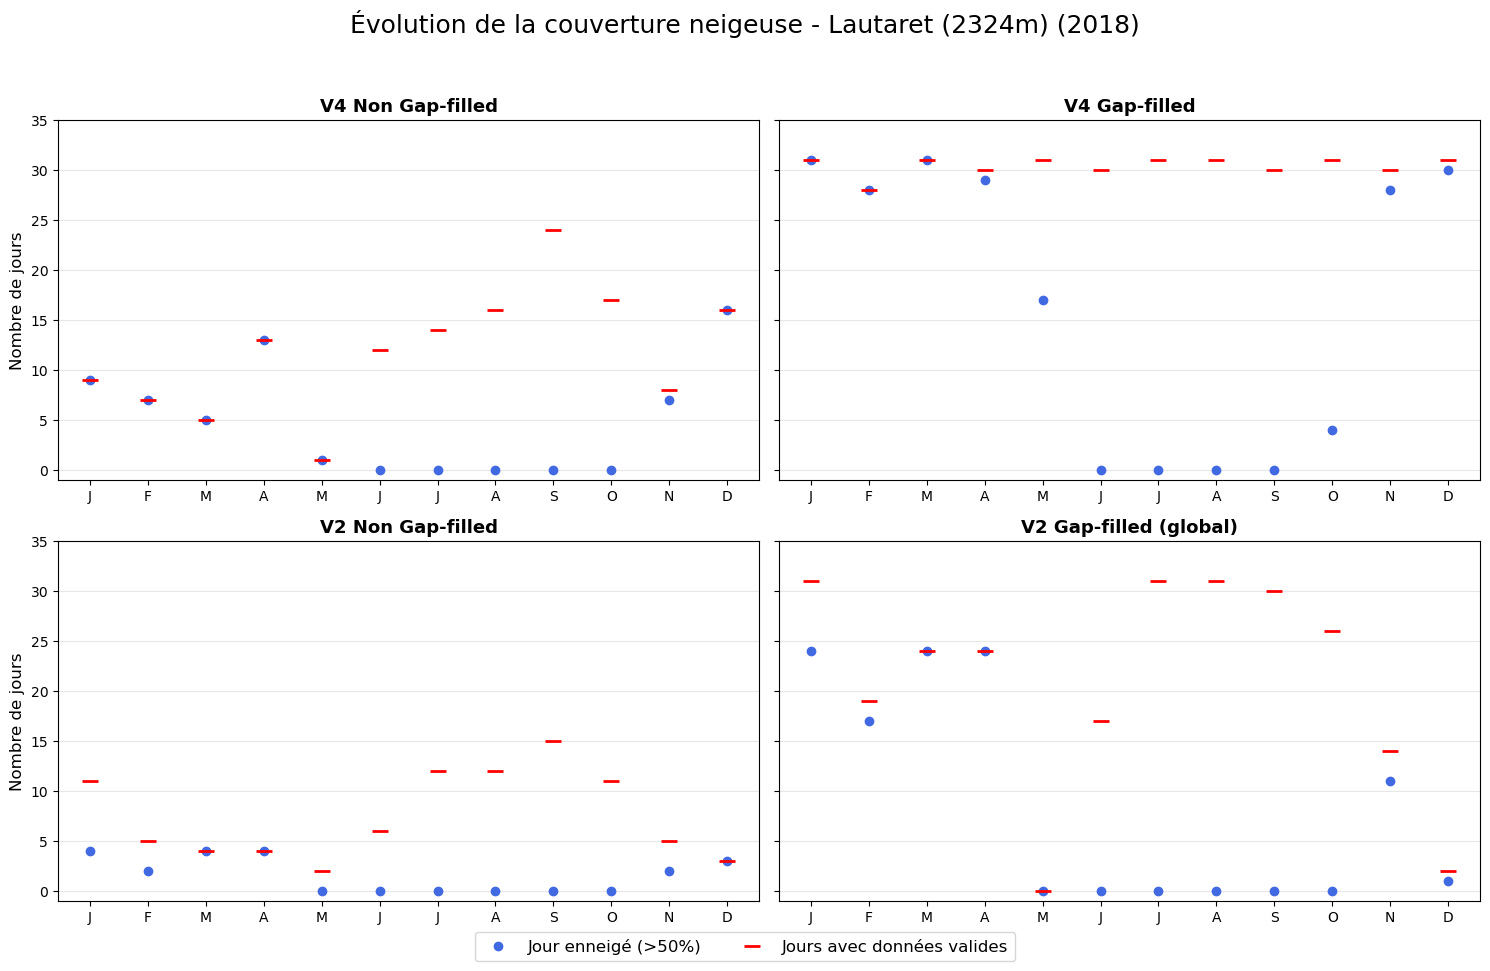

In [6]:
lon_site, lat_site =  6.4, 45.0 
lieu ="Lautaret"
year = "2018"
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values
lieu_titre = f"{lieu} ({int(alt_site)}m)"

output_dir = '/home/mougina/mes_analyses/'
os.makedirs(output_dir, exist_ok=True)

paths = [
    ("V4 Non Gap-filled", "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_NGF_global/2018/**/*.nc", "multi"),
    ("V4 Gap-filled", "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_2018.nc", "single"),
    ("V2 Non Gap-filled", "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_2018.nc", "single"),
    ("V2 Gap-filled (global)", "/home/mougina/mes_analyses/Alpine_snow.nc", "global")
]

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axs = axs.flatten()
months = ['J','F','M','A','M','J','J','A','S','O','N','D']

for i, (label, path, ptype) in enumerate(paths):
    if ptype == "multi":
        ds = xr.open_mfdataset(path, combine='by_coords', decode_cf=True, parallel=True)
    else:
        ds_raw = xr.open_dataset(path, decode_cf=False)
        for v in ds_raw.variables:
            if 'dtype' in ds_raw[v].attrs: del ds_raw[v].attrs['dtype']
        ds = xr.decode_cf(ds_raw)
    var_name = 'scfg_interp' if ptype == "global" else 'scfg'
    temp_ds = ds.sel(time=year) if ptype == "global" else ds

    test_point = temp_ds[var_name].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
    
    # 4. Calculs
    vrai_neige = ((test_point > 50) & (test_point <= 100)).groupby('time.month').sum(dim='time')
    jour_mesure = ((test_point >= 0) & (test_point <= 100)).groupby('time.month').sum(dim='time')
    
    # 5. Plot
    ax = axs[i]
    ax.plot(range(1, 13), vrai_neige.values, 'o', color='royalblue', label="Jour enneigé (>50%)")
    ax.plot(range(1, 13), jour_mesure.values, '_', markersize=12, markeredgewidth=2, color='red', label="Jours avec données valides")
    
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months)
    ax.set_ylim(-1, 35)
    ax.grid(axis='y', alpha=0.3)
    if i % 2 == 0: ax.set_ylabel("Nombre de jours", fontsize=12)

# --- LÉGENDE UNIQUE ---
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=12)

plt.suptitle(f"Évolution de la couverture neigeuse - {lieu_titre} ({year})", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Laisse de la place pour titre et légende

# Sauvegarde
plt.savefig(os.path.join(output_dir, f'comparaison_neige_{lieu_titre}_2018.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

fig, (ax_v4, ax_v2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

ax_v4.plot(range(1, 13), axs[1].get_lines()[0].get_ydata(), 'o', color='cyan', label="V4 GF (snow)")
ax_v4.plot(range(1, 13), axs[1].get_lines()[1].get_ydata(), '_', color='royalblue', label="V4 GF (days measured)")
ax_v4.plot(range(1, 13), axs[0].get_lines()[0].get_ydata(), '.', color='red', label="V4 NGF (snow)")
ax_v4.plot(range(1, 13), axs[0].get_lines()[1].get_ydata(), '_', color='magenta', label="V4 NGF (days measured)")


ax_v2.plot(range(1, 13), axs[3].get_lines()[0].get_ydata(), 'o', color='cyan', label="V2 GF (snow)")
ax_v2.plot(range(1, 13), axs[3].get_lines()[1].get_ydata(), '_', color='royalblue', label="V2 GF (days measured)")
ax_v2.plot(range(1, 13), axs[2].get_lines()[0].get_ydata(), '.', color='red', label="V2 NGF (snow)")
ax_v2.plot(range(1, 13), axs[2].get_lines()[1].get_ydata(), '_', color='magenta', label="V2 NGF (days measured)")

ax_v4.set_title("V4 gap-filled and not gap-filled")
ax_v2.set_title("V2 gap-filled and not gap-filled")
for ax in [ax_v4, ax_v2]:
    ax.set_ylim(-1, 40)
    ax.legend(ncol=2, fontsize=9, loc='upper right')
    ax.grid(alpha=0.2)
    ax.set_ylabel("Days number", fontsize=10)
    ax.set_xlabel("Month", fontsize=10)
ax_v2.set_xticks(range(1, 13))
ax_v2.set_xticklabels(months)
plt.suptitle(f"Comparison Snow cover - col du {lieu_titre} ({year})", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'comparaison_neige_{lieu_titre}_2018_v2_vs_v4.png'), dpi=150, bbox_inches='tight')
plt.show()



In [ ]:

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

fig, (ax_v4, ax_v2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

x_base = np.arange(1, 13)
offset = 0.05 
x_gf = x_base - offset
x_ngf = x_base + offset
colors = {
    "gf_snow": "#1f77b4",       
    "gf_days": "#aec7e8",
    "ngf_snow": "#ff7f0e",      
    "ngf_days": "#ffbb78"       
}

ax_v4.plot(x_gf, axs[1].get_lines()[0].get_ydata(), marker='o', markersize=6,  color=colors["gf_snow"], label="Gap-Filled (neige)")
ax_v4.plot(x_gf, axs[1].get_lines()[1].get_ydata(), marker='s', markersize=5, color=colors["gf_days"], label="Gap-Filled (jours mesurés)")
ax_v4.plot(x_ngf, axs[0].get_lines()[0].get_ydata(), marker='o', markersize=6, color=colors["ngf_snow"], label="Non Gap-Filled (neige)")
ax_v4.plot(x_ngf, axs[0].get_lines()[1].get_ydata(), marker='s', markersize=5, color=colors["ngf_days"], label="Non Gap-Filled (jours mesurés)")

ax_v2.plot(x_gf, axs[3].get_lines()[0].get_ydata(), marker='o', markersize=6, color=colors["gf_snow"], label="Gap-Filled (neige)")
ax_v2.plot(x_gf, axs[3].get_lines()[1].get_ydata(), marker='s', markersize=5,  color=colors["gf_days"], label="Gap-Filled (jours mesurés)")
ax_v2.plot(x_ngf, axs[2].get_lines()[0].get_ydata(), marker='o', markersize=6, color=colors["ngf_snow"], label="Non Gap-Filled (neige)")
ax_v2.plot(x_ngf, axs[2].get_lines()[1].get_ydata(), marker='s', markersize=5, color=colors["ngf_days"], label="Non Gap-Filled (jours mesurés)")

ax_v4.set_title("Version V4 avec ou sans gap-filling", fontsize=12, fontweight='bold', pad=12, color='#333333')
ax_v2.set_title("Version V2 avec ou sans gap-filling", fontsize=12, fontweight='bold', pad=12, color='#333333')

for ax in [ax_v4, ax_v2]:
    ax.set_ylim(-1, 38)
    ax.set_xlabel("Mois", fontsize=13, labelpad=8)
    ax.grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')

    ax.legend(ncol=2, fontsize=10, loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='none')
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_v4.set_ylabel("Nombre de jours", fontsize=12, labelpad=8)
ax_v4.set_xticks(x_base)
ax_v4.set_xticklabels(months, rotation=25, ha='right', fontsize=12)
ax_v2.set_xticklabels(months, rotation=25, ha='right', fontsize=12)


plt.suptitle(f"Comparaison de la Snow Cover Duration (SCD) — Col du {lieu_titre} ({year})", 
             fontsize=13, fontweight='bold', color='#222222', y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'comparaison_neige_{lieu_titre}_2018_v2_vs_v4.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

IndexError: list index out of range

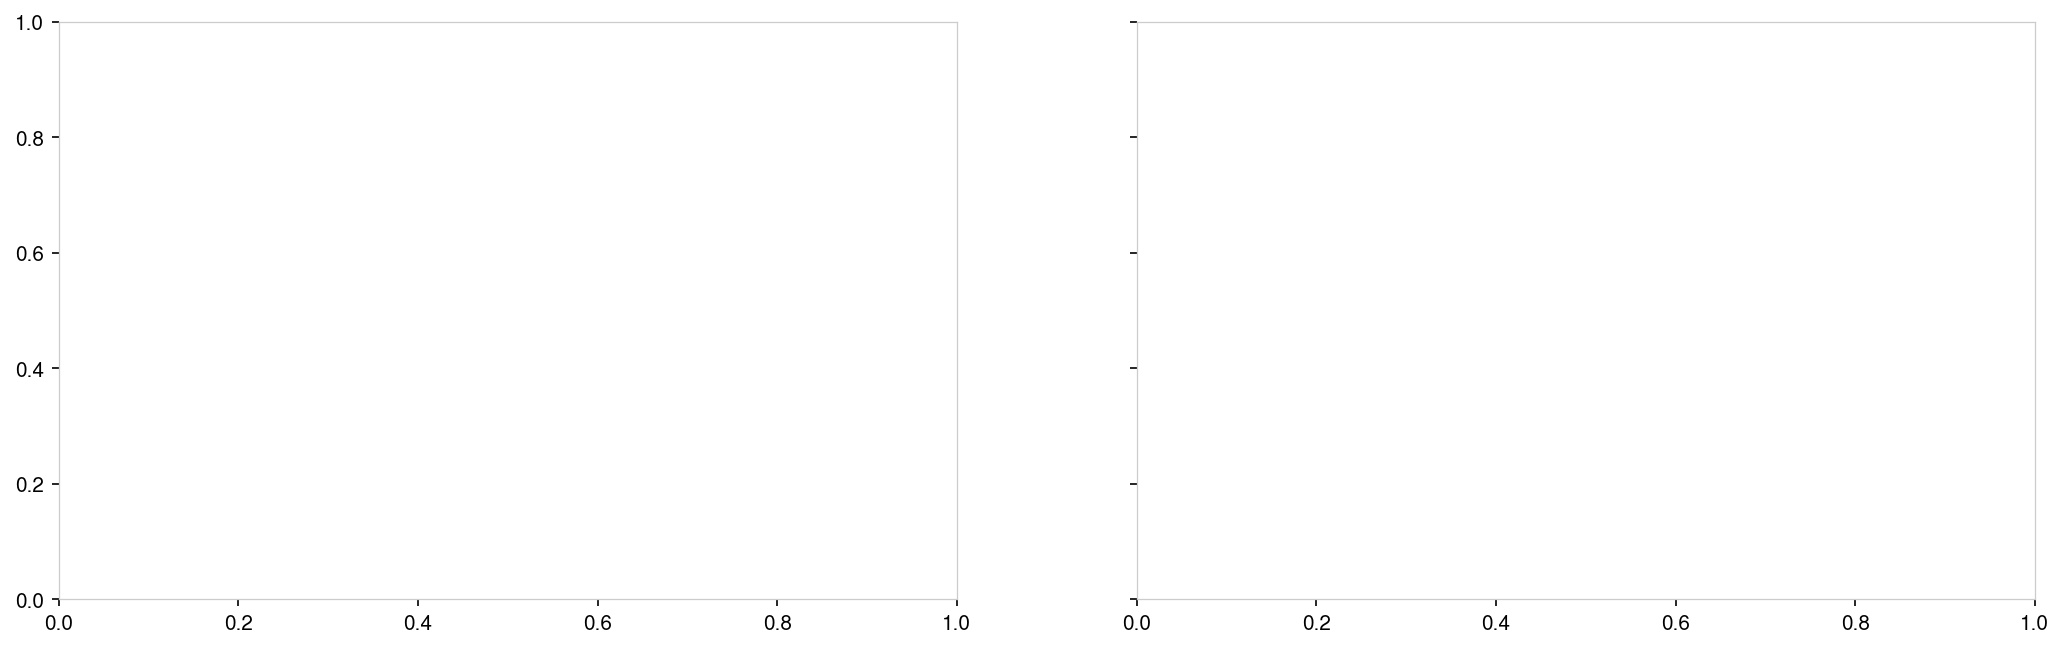

In [17]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.6

fig, (ax_v4, ax_v2) = plt.subplots(1, 2, figsize=(17, 5), sharex=True, sharey=True)

x_base = np.arange(1, 13)
offset = 0.03
x_gf = x_base - offset
x_ngf = x_base + offset
colors = {
    "gf_total": "#a6c8e0",   
    "gf_snow": "#1d6393",    
    "ngf_total": "#fbc490",  
    "ngf_snow": "#d96b27"    
}


ax_v4.bar(x_base, axs[1].get_lines()[1].get_ydata(), width=0.55, color=colors["gf_total"], alpha=0.8, label="Obs. (GF)", edgecolor= 'steelblue')
ax_v4.bar(x_base, axs[0].get_lines()[1].get_ydata(), width=0.32, color=colors["ngf_total"], alpha=0.8, label="Obs. (NGF)",hatch = '/', edgecolor='peru')
ax_v4.plot(x_gf, axs[1].get_lines()[0].get_ydata(), marker='o', markersize=6, color=colors["gf_snow"], label="Neige (GF)")
ax_v4.plot(x_ngf, axs[0].get_lines()[0].get_ydata(), marker='s', markersize=5, color=colors["ngf_snow"], label="Neige (NGF)")

ax_v2.bar(x_base, axs[3].get_lines()[1].get_ydata(), width=0.55, color=colors["gf_total"], alpha=0.8, label="Obs. (GF)", edgecolor= 'steelblue')
ax_v2.bar(x_base, axs[2].get_lines()[1].get_ydata(), width=0.32, color=colors["ngf_total"], alpha=0.8, label="Obs. (NGF)",hatch = '/', edgecolor='peru')
ax_v2.plot(x_gf, axs[3].get_lines()[0].get_ydata(), marker='o', markersize=6, color=colors["gf_snow"], label="Neige (GF)")
ax_v2.plot(x_ngf, axs[2].get_lines()[0].get_ydata(), marker='s', markersize=5, color=colors["ngf_snow"], label="Neige (NGF)")

ax_v4.set_title("Version V4", fontsize=16, color='#333333', fontweight = 'bold')
ax_v2.set_title("Version V2", fontsize=16, color='#333333', fontweight = 'bold')
ax_v2.legend(ncol=2, fontsize=14, loc='upper right', frameon=False)
for ax in [ax_v4, ax_v2]:
    ax.set_ylim(-1, 39)
    ax.grid(True, linestyle='--', alpha=0.3, color='#bbbbbb', axis='y')
    #ax.legend(ncol=2, fontsize=12, loc='upper right', frameon=False)
    ax.set_xlabel("Mois", fontsize=15, labelpad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_v4.set_ylabel("Jours par mois", fontsize=15, color='#333333')
ax_v4.set_xticks(x_base)
ax_v4.set_xticklabels(months, rotation=0, fontsize=13)

plt.suptitle(f"Disponibilités des données et SCD autour du col du {lieu_titre} ({year}) avec les différentes versions SNOW-CCI  ", fontsize=17, color='#222222', weight="bold",y=0.99)
plt.savefig(os.path.join(output_dir, f'comparaison_neige_{lieu_titre}_2018_v2_vs_v4_histo.png'))
plt.tight_layout()
plt.show()

In [8]:
years = [2016,2017, 2018]

In [9]:

list_v4 = []
for yr in years:
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0).where(ds_v['scfg'] <= 100)
    list_v4.append(ds_v['scfg'])
all_v4 = xr.concat(list_v4, dim='time')
time_pd_v4 = all_v4.time.to_index()
season_labels_v4 = [get_season(t) for t in time_pd_v4]
all_v4 = all_v4.assign_coords(season=('time', season_labels_v4))

winter_v4 = xr.concat([
    all_v4.where(all_v4.season == f"{yr}_DJF", drop=True) for yr in years
], dim='time').mean(dim='time')
winter_v4 = winter_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
winter_v4 = winter_v4.where(alps_ice == True)

In [10]:
list_v2 = []
for yr in years:
    v2_yr = scfg_final.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
    list_v2.append(v2_yr)
all_v2 = xr.concat(list_v2, dim='time')
time_pd_v2 = all_v2.time.to_index()
season_labels_v2 = [get_season(t) for t in time_pd_v2]
all_v2 = all_v2.assign_coords(season=('time', season_labels_v2))

winter_v2 = xr.concat([
    all_v2.where(all_v2.season == f"{yr}_DJF", drop=True) for yr in years
], dim='time').mean(dim='time')
winter_v2 = winter_v2.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
winter_v2 = winter_v2.where(alps_ice == True)

In [12]:
list_v4_ngf = []
for yr in years:
    ds_ngf = xr.open_mfdataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_NGF_global/{yr}/**/*.nc",
                                combine='by_coords', decode_cf=True, parallel=True)
    ds_ngf['scfg'] = ds_ngf['scfg'].where(ds_ngf['scfg'] >= 0).where(ds_ngf['scfg'] <= 100)
    list_v4_ngf.append(ds_ngf['scfg'])
all_v4_ngf = xr.concat(list_v4_ngf, dim='time')
time_pd_v4_ngf = all_v4_ngf.time.to_index()
season_labels_v4_ngf = [get_season(t) for t in time_pd_v4_ngf]
all_v4_ngf = all_v4_ngf.assign_coords(season=('time', season_labels_v4_ngf))

winter_v4_ngf = xr.concat([
    all_v4_ngf.where(all_v4_ngf.season == f"{yr}_DJF", drop=True) for yr in years
], dim='time').mean(dim='time')
winter_v4_ngf = winter_v4_ngf.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
winter_v4_ngf = winter_v4_ngf.where(alps_ice == True)

In [14]:
import glob
import xarray as xr
import numpy as np

data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_20*.nc"
files = sorted(glob.glob(data_path))

if not files:
    raise FileNotFoundError(f"Aucun fichier trouvé dans {data_path}")

ds_ref = xr.open_dataset(files[0])
ref_lat = ds_ref.lat
ref_lon = ds_ref.lon

def preprocess_modis_final(ds):  
    variables_to_drop = ['lat_bnds', 'lon_bnds', 'spatial_ref', 'scfg_unc']
    ds = ds.drop_vars([v for v in variables_to_drop if v in ds.variables])
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    ds = ds.reindex(lat=ref_lat, lon=ref_lon, method='nearest')
    return ds

ds = xr.open_mfdataset(files,combine='nested',concat_dim='time',preprocess=preprocess_modis_final,coords='minimal',compat='override',join='override',decode_cf=True
)
scfg = ds['scfg'].where((ds['scfg'] >= 0) & (ds['scfg'] <= 100))
time_pd = scfg.time.to_index()
season_labels = [get_season(t) for t in time_pd]
scfg = scfg.assign_coords(season=('time', season_labels))
target_winters = [f"{yr}_DJF" for yr in years]
winter_avg = scfg.where(scfg.season.isin(target_winters), drop=True).mean(dim='time')

print("--- VÉRIFICATION 1 : Après moyenne temporelle d'hiver ---")
print("Nombre de pixels valides :", int(winter_avg.notnull().sum()))
if (winter_avg.lon > 180).any():
    winter_avg = winter_avg.assign_coords(lon=(((winter_avg.lon + 180) % 360) - 180))
    winter_avg = winter_avg.sortby('lon')
winter_final = winter_avg.interp(
    lon=ds_grid.LON, 
    lat=ds_grid.LAT, 
    method="linear", 
    kwargs={'fill_value': np.nan}
)

print("\n--- VÉRIFICATION 2 : Après interpolation ---")
print("Nombre de pixels valides :", int(winter_final.notnull().sum()))
winter_final = winter_final.where(alps_ice == True)

print("\n--- VÉRIFICATION 3 : Après masque alps_ice ---")
print("Nombre de pixels valides :", int(winter_final.notnull().sum()))

--- VÉRIFICATION 1 : Après moyenne temporelle d'hiver ---
Nombre de pixels valides : 19641

--- VÉRIFICATION 2 : Après interpolation ---
Nombre de pixels valides : 8308

--- VÉRIFICATION 3 : Après masque alps_ice ---
Nombre de pixels valides : 3450


In [ ]:

plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':       10,
    'axes.titlesize':  11,
    'figure.dpi':      150,
})

panels = [
    ("V4 NGF", winter_v4_ngf),
    ("V4 GF",  winter_v4),
    ("V2 NGF", winter_final),
    ("V2 GF",  winter_v2),
]

grey_mask = np.where(alps, np.nan, 0.2)

fig, axs = plt.subplots(2, 2, figsize=(13, 7.2),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        constrained_layout=True)
axs = axs.flatten()

for idx, (label, data) in enumerate(panels):
    ax = axs[idx]
    lettre = f"({chr(97 + idx)})"
    ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                  cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
    im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, data.where(alps_ice == True),
                       cmap='viridis', vmin=0, vmax=100, transform=ccrs.PlateCarree())
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0, transform=ccrs.PlateCarree())
    ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top',
            bbox=dict(fc='white', ec='none', alpha=0.7))
    scf_mean = float(np.nanmean(data.where(alps_ice == True)))
    ax.set_title(f"{label} (Moyenne = {scf_mean:.1f}%)", fontsize=14, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    if idx % 2 != 0:
        gl.left_labels = False
    if idx < 2:
        gl.bottom_labels = False
        
    
cbar= fig.colorbar(im, ax=axs, location='bottom', fraction=0.08, pad=0.04, shrink=0.4)
cbar.set_label('SCF moyenne DJF (%)', fontsize=14)

plt.suptitle("SCF moyenne hivernale (DJF 2017–2018) — Alpes\nComparaison des 4 versions", size=15, fontweight='bold')
plt.savefig('/home/mougina/mes_analyses/comparaison_MAR_v4etv2/carte_SCF_DJF_4versions_propre.png', dpi=100)
plt.show()

### Les cartes comme au debut mais cette fois ci sur toutes les annees que j'ai a ma disposition 

In [ ]:


data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_20*.nc"
first_year = 2016
last_year = 2021
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_mfdataset(
    sorted(glob.glob(data_path)), 
    combine='by_coords',
    preprocess=fix_dtype_conflict,
    decode_cf=False  
)
ds = xr.decode_cf(ds_raw)

ds = ds.sel(time=slice(f'{first_year}-01-01', f'{last_year}-12-31'))

scfg = ds['scfg'].where(ds['scfg'] <= 100)

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):
    m = ax.pcolormesh(
        ds.lon, ds.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=31,
        transform=ccrs.PlateCarree()
    )
    ax.set_title(months[i], fontsize=13)
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False
    ax.contour(
        dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,
        levels=[1000],
        colors='black', 
        linewidths=0.8,
        transform=ccrs.PlateCarree(),
        zorder=2 
    )
cbar = fig.colorbar(m, ax=axs, label='jour neige / mois',
                    fraction=0.05, aspect=100)
fig.suptitle(f"jour de neige mensuel v4 GF{first_year}-{last_year}",
             fontsize=15)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/v4_gap_filled/snow_monthly_mean_v4GFall.png', dpi=150)
plt.show()

In [ ]:

save_data = '/home/mougina/mes_analyses_neige'
data_file = save_data + '/Alpine_snow.nc'

first_year = 1982
last_year = 2018
lat1, lat2, lon1, lon2 = 43, 48, 5, 17
def fix_dtype_conflict(ds):
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    return ds

ds_raw = xr.open_dataset(
    data_file, 
    decode_cf=False, 
    chunks={'time': 100, 'lat': 100, 'lon': 100} 
)

ds_raw = fix_dtype_conflict(ds_raw)
ds = xr.decode_cf(ds_raw)

scfg = ds['scfg_interp'].sel(time=slice(str(first_year), str(last_year)))

seuil = 50
est_enneige = (scfg > seuil).astype(int)

monthly_days = est_enneige.groupby('time.month').sum(dim='time')

n_annees = (last_year - first_year) + 1
monthly_days_avg = monthly_days / n_annees

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

fig, axs = plt.subplots(3, 4, figsize=(18, 8),
                        subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axs.flat):

    m = ax.pcolormesh(
        ds.lon, ds.lat,
        monthly_days_avg.sel(month=i+1),
        cmap='Blues', vmin=0, vmax=31,
        transform=ccrs.PlateCarree()
    )
    ax.set_title(months[i], fontsize=13)
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', color='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False
        
    ax.contour(
        dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,
        levels=[1000],
        colors='black', 
        linewidths=0.8,
        transform=ccrs.PlateCarree(),
        zorder=2 
    )

cbar = fig.colorbar(m, ax=axs, label='Snow Cover Fraction (%)',
                    fraction=0.05, aspect=100)
fig.suptitle(f"jour de neige mensuel v2 GF(SNOW-CCI) {first_year}-{last_year}",
             fontsize=15, fontweight='bold')

plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/v2_gap_filled/snow_cci_monthly_mean_{first_year}_{last_year}.png', dpi=150)
plt.show()

print(ds.time.max().values)
print(ds.time.tail(5).values)

In [ ]:

ds = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.2018.nc")
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

snow_height = ds['ZN3']

snow_height_s0 = snow_height.sel(sector=3)

print(snow_height_s0)

## Comparaison avec MAR

pour conmencer on fait avec la ZN3 (avec un seuil que j'ai remis a 0.01 au lieu de 0 suite au conseil de martin, je vais aussi tester avec plusieurs seuil dans le nouveau notebook "snowcover_v2-v4_CCISNOW_compare_to_MAR_ERA5" consacrer a MAR et ces comparaisons avec la v2 et la v4 GF) qui donne la hauteur de neige et ensuite avec la MB qui donne le total snow water equivalent dont le seuil est reste a 0 pour linstant.

#### ZN3 :

In [ ]:

ds_data = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
ds_data = ds_data.assign_coords(lon=ds_grid.LON, lat=ds_grid.LAT)
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

scfg = (ds_data['ZN3'].isel(sector=0) > 0.1).astype(float) * 100  ### ici le sup s 
monthly_mean = scfg.groupby('time.month').sum(dim='time')
n_annees = 1 
monthly_days_avg = monthly_days / n_annees

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


fig, axs = plt.subplots(3, 4, figsize=(18, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree()}) 

for i, ax in enumerate(axs.flat):
    if i < len(monthly_days_avg.month):
        m = ax.pcolormesh(
            ds_data.lon, ds_data.lat,
            monthly_days_avg.sel(month=i+1),
            cmap='Blues', vmin=0, vmax=31,
            transform=ccrs.PlateCarree())
        ax.coastlines(resolution='50m', color='black', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        
        ax.set_title(months[i], fontsize=13)
        ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[1000],colors='black',
            linewidths=0.8,
            transform=ccrs.PlateCarree(),
            zorder=2)
        gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        if i < 8: gl.bottom_labels = False 
        if i % 4 != 0: gl.left_labels = False
    else:
        ax.axis('off')

cbar = fig.colorbar(m, ax=axs, label='jour neige / mois',
                    fraction=0.05, aspect=100)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/MAR/snow_monthly_mean_2018_Alpes_MAR.png', dpi=150)

plt.show()

#### MB : 

In [ ]:

ds_data = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.MB.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
ds_data = ds_data.assign_coords(lon=ds_grid.LON, lat=ds_grid.LAT)
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

scfg = (ds_data['MB'].isel(sector=0) > 0.1).astype(float) * 100  
monthly_mean = scfg.groupby('time.month').sum(dim='time')
n_annees = 1 
monthly_days_avg = monthly_days / n_annees


months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


fig, axs = plt.subplots(3, 4, figsize=(18, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree()}) 

for i, ax in enumerate(axs.flat):
    if i < len(monthly_days_avg.month):
        m = ax.pcolormesh(
            ds_data.lon, ds_data.lat,
            monthly_days_avg.sel(month=i+1),
            cmap='Blues', vmin=0, vmax=31,
            transform=ccrs.PlateCarree())
        ax.coastlines(resolution='50m', color='black', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        
        ax.set_title(months[i], fontsize=13)
        ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[1000],colors='black',
            linewidths=0.8,
            transform=ccrs.PlateCarree(),
            zorder=2)
        gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        if i < 8: gl.bottom_labels = False 
        if i % 4 != 0: gl.left_labels = False
    else:
        ax.axis('off')

cbar = fig.colorbar(m, ax=axs, label='nb jours neige / mois (%)',
                    fraction=0.05, aspect=100)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/MAR/snow_monthly_mean_2018_Alpes_MAR.png', dpi=150)

plt.show()

ZN3 sur une zone precise (ici autour du Lautaret)

In [ ]:

ds_data = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
ds_data = ds_data.assign_coords(lon=ds_grid.LON, lat=ds_grid.LAT)
lat1, lat2, lon1, lon2 = 45, 45.3, 5.8, 6.3  #belledonne                 #43, 48, 5, 17
lieu = 'Lautaret'
scfg = (ds_data['ZN3'].isel(sector=0) > 0.1).astype(float) * 100  
monthly_mean = scfg.groupby('time.month').sum(dim='time')
n_annees = 1 
monthly_days_avg = monthly_days / n_annees


months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


fig, axs = plt.subplots(3, 4, figsize=(18, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree()}) 

for i, ax in enumerate(axs.flat):
    if i < len(monthly_days_avg.month):
        m = ax.pcolormesh(
            ds_data.lon, ds_data.lat,
            monthly_days_avg.sel(month=i+1),
            cmap='Blues', vmin=0, vmax=31,
            transform=ccrs.PlateCarree())
        ax.coastlines(resolution='50m', color='black', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        
        ax.set_title(months[i], fontsize=13)
        cs = ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[500,1000,1500,2000,2500,3000,3500],colors='grey',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=2)
        ax.clabel(cs, inline=True, fontsize=7, fmt='%1.0f',  colors='grey')
        gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        if i < 8: gl.bottom_labels = False 
        if i % 4 != 0: gl.left_labels = False
    else:
        ax.axis('off')

cbar = fig.colorbar(m, ax=axs, label='nb jours neige / mois ',
                    fraction=0.05, aspect=100)
fig.suptitle(f" nombre jour neige mensuel SCF MAR ERA 5  2018 {lieu}")
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/MAR/snow_monthly_mean_2018_{lieu}_MAR.png', dpi=150)
plt.show()

MB 

In [ ]:

ds_data = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.MB.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
ds_data = ds_data.assign_coords(lon=ds_grid.LON, lat=ds_grid.LAT)
lat1, lat2, lon1, lon2 = 45, 45.3, 5.8, 6.3                           #43, 48, 5, 17

scfg = (ds_data['MB'].isel(sector=0) > 0.1).astype(float) * 100  
monthly_mean = scfg.groupby('time.month').sum(dim='time')
n_annees = 1 
monthly_days_avg = monthly_days / n_annees

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


fig, axs = plt.subplots(3, 4, figsize=(18, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree()}) 

for i, ax in enumerate(axs.flat):
    if i < len(monthly_days_avg.month):
        m = ax.pcolormesh(
            ds_data.lon, ds_data.lat,
            monthly_days_avg.sel(month=i+1),
            cmap='Blues', vmin=0, vmax=30,
            transform=ccrs.PlateCarree())
        ax.coastlines(resolution='50m', color='black', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        
        ax.set_title(months[i], fontsize=13)
        cs = ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[500,1000,1500,2000,2500,3000,3500],colors='grey',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=2)
        ax.clabel(cs, inline=True, fontsize=7, fmt='%1.0f',  colors='grey')
        gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        if i < 8: gl.bottom_labels = False 
        if i % 4 != 0: gl.left_labels = False
    else:
        ax.axis('off')

cbar = fig.colorbar(m, ax=axs, label='jours de neige / mois',
                    fraction=0.05, aspect=100)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/MAR/snow_monthly_mean_2018_Belledonne_MAR.png', dpi=150)
plt.show()

Verification en un point comme pour les donnees reels

In [ ]:
ds_data = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
lon_site, lat_site = 6.4, 45.0
lieu = "Col du Lautaret"
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values
lieu_titre = f"{lieu} ({int(alt_site)}m)"

dist = ((ds_grid.LON - lon_site)**2 + (ds_grid.LAT - lat_site)**2)
point_data = ds_data['ZN3'].isel(sector=0).where(dist == dist.min(), drop=True).squeeze()

is_snowy = (point_data > 0).astype(int)
vrai_neige = is_snowy.groupby('time.month').sum(dim='time')
jour_mesure = point_data.notnull().groupby('time.month').sum(dim='time')
plt.figure(figsize=(8, 5))
months_range = range(1, 13)

plt.plot(months_range, vrai_neige.values, 'o', color='royalblue', label="Jour enneigé (MAR)")
plt.plot(months_range, jour_mesure.values, '_', markersize=20, markeredgewidth=2, color='red', label="Jours simulés")


plt.ylabel("Nombre de jours")
plt.xticks(months_range, ['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylim(-2, 35)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.tight_layout()
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu_titre} en 2018 avec MAR.png', dpi=100)
plt.show()

### Comapraison moyenne mensuelle sur v4 GP et Le MAR ERA 5

In [ ]:

lon_site, lat_site = 6.4, 45.0
lieu = "Lautaret"
year = "2018"

path_v4 = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_2018.nc"
ds_v4_raw = xr.open_dataset(path_v4, decode_cf=False)
for v in ds_v4_raw.variables:
    if 'dtype' in ds_v4_raw[v].attrs: del ds_v4_raw[v].attrs['dtype']
ds_v4 = xr.decode_cf(ds_v4_raw)

ds_mar = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")

test_v4 = ds_v4['scfg'].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
vrai_neige_v4 = ((test_v4 > 50) & (test_v4 <= 100)).groupby('time.month').sum()


dist = ((ds_grid.LON - lon_site)**2 + (ds_grid.LAT - lat_site)**2)
alt_site = ds_grid['SH'].where(dist == dist.min(), drop=True).values[0]
lieu_titre = f"{lieu} ({int(alt_site)}m)"


test_mar = ds_mar['ZN3'].isel(sector=0).where(dist == dist.min(), drop=True).squeeze()
vrai_neige_mar = (test_mar > 0).astype(int).groupby('time.month').sum()

jour_mesure = test_mar.notnull().groupby('time.month').sum()

plt.figure(figsize=(10, 6))
months_range = np.arange(1, 13)
months_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

plt.plot(months_range, jour_mesure.values, '_', markersize=10, markeredgewidth=1.5, color='red', label="Jours dans le mois", zorder=1)

plt.plot(months_range, vrai_neige_v4.values, 'o', color='royalblue', linewidth=2, label="Satellite (V4 Gap-filled)", zorder=3)

plt.plot(months_range + 0.1, vrai_neige_mar.values, 's', color='forestgreen', linewidth=1.5, label="Modèle MAR ERA 5 ", alpha=0.8, zorder=2)

plt.ylabel("Nombre de jours de neige", fontsize=12)
plt.xticks(months_range, months_labels)
plt.ylim(-1, 35)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=True)

plt.tight_layout()
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu_titre} en 2018 avec MAR compare a v4 GP.png', dpi=100)
plt.show()

In [ ]:

lon_site, lat_site = 5.5261230,45.1265934
lieu = "Meaudre"
annees = range(2017, 2021)

ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
dist = ((ds_grid.LON - lon_site)**2 + (ds_grid.LAT - lat_site)**2)
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values


all_v4_months = []
all_mar_months = []
time_labels = []

for year in annees:
    #MAR
    file_mar = f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{year}.nc"
    ds_m = xr.open_dataset(file_mar).isel(sector=0)
    pt_m = ds_m['ZN3'].where(dist == dist.min(), drop=True).squeeze()
    
    mar_monthly = (pt_m > 0).astype(int).groupby('time.month').sum()
    all_mar_months.append(mar_monthly.values)
    #V4
    file_v4 = f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{year}.nc"
    ds_v4_raw = xr.open_dataset(file_v4, decode_cf=False)
    for v in ds_v4_raw.variables:
        if 'dtype' in ds_v4_raw[v].attrs: del ds_v4_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v4_raw)
    
    pt_v = ds_v['scfg'].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
    v4_monthly = ((pt_v > 50) & (pt_v <= 100)).groupby('time.month').sum()
    all_v4_months.append(v4_monthly.values)

    for m in range(1, 13):
        time_labels.append(f"{m:02d}-{year}")

y_mar = np.concatenate(all_mar_months)
y_v4 = np.concatenate(all_v4_months)
x_axis = np.arange(len(time_labels))

plt.figure(figsize=(18, 6))

plt.plot(x_axis, y_v4, 'o-', color='royalblue', label="V4 Gap-filled", linewidth=1.5)
plt.plot(x_axis, y_mar, 's--', color='forestgreen', label="MAR ERA 5", alpha=0.7)

plt.xticks(x_axis[::3], time_labels[::3], rotation=45, fontsize=9)

for i in range(1, len(annees)):
    plt.axvline(i * 12 - 0.5, color='black', linestyle=':', alpha=0.3)

plt.title(f"Enneigement au {lieu} ({int(alt_site)}m) - 2017 à 2020", fontsize=15)
plt.ylabel("Nombre de jours de neige / mois")
plt.ylim(-1, 33)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper right')
#plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu} sur 4 ans avec MAR compare a v4 GP.png', dpi=100)
plt.tight_layout()
plt.show()

**2eme MAR avec cette fois ci apres 2015 des prevision sous SSP585**

Pas de hauteur de neige ici donc je  fais avec le snow water equivalent en disant si sup a zero alors couverture de neige egal 1. Dans tout ca on sait que le MARA SSP5 8.5 et pas utile pour ce gerne de travail a cote du ERA 5

In [ ]:

ds_data = xr.open_dataset("/bettik/castelli/data/MAR-MPI-ESM/v3.14/bigdomain/SSP585/ICE.MPI-ESM_SSP585.EUn.MB.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-MPI-ESM/v3.14/bigdomain/MARgrid_EUn.nc")
ds_data = ds_data.assign_coords(lon=ds_grid.LON, lat=ds_grid.LAT)
lat1, lat2, lon1, lon2 = 43, 48, 5, 17

scfg = (ds_data['MB'].isel(sector=0) > 0).astype(float) * 100  # a 0 car ici on a un SWE et pas une hauteur de neige 
monthly_mean = scfg.groupby('time.month').mean(dim='time').compute()

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


fig, axs = plt.subplots(3, 4, figsize=(18, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree()}) 

for i, ax in enumerate(axs.flat):
    if i < len(monthly_mean.month):
        m = ax.pcolormesh(
            ds_data.lon, ds_data.lat,
            monthly_mean.sel(month=i+1),
            cmap='Blues', vmin=0, vmax=100,
            transform=ccrs.PlateCarree())
        ax.coastlines(resolution='50m', color='black', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        
        ax.set_title(months[i], fontsize=13)
        ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[1000],colors='black',
            linewidths=0.8,
            transform=ccrs.PlateCarree(),
            zorder=2)
        gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        if i < 8: gl.bottom_labels = False 
        if i % 4 != 0: gl.left_labels = False
    else:
        ax.axis('off')

cbar = fig.colorbar(m, ax=axs, label='Snow Cover Fraction (%)',
                    fraction=0.05, aspect=100)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/MAR/snow_monthly_mean_2018_Alpes_MAR.png', dpi=150)

plt.show()

In [ ]:

ds_data = xr.open_dataset("/bettik/castelli/data/MAR-MPI-ESM/v3.14/bigdomain/SSP585/ICE.MPI-ESM_SSP585.EUn.MB.2018.nc")
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-MPI-ESM/v3.14/bigdomain/MARgrid_EUn.nc")
ds_data = ds_data.assign_coords(lon=ds_grid.LON, lat=ds_grid.LAT)
lat1, lat2, lon1, lon2 = 45, 45.3, 5.8, 6.3                           #43, 48, 5, 17

scfg = (ds_data['MB'].isel(sector=0) > 0).astype(float) * 100  # a 0 car ici on a un SWE et pas une hauteur de neige 
monthly_mean = scfg.groupby('time.month').mean(dim='time').compute()

months = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
          'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


fig, axs = plt.subplots(3, 4, figsize=(18, 8), 
                        subplot_kw={'projection': ccrs.PlateCarree()}) 

for i, ax in enumerate(axs.flat):
    if i < len(monthly_mean.month):
        m = ax.pcolormesh(
            ds_data.lon, ds_data.lat,
            monthly_mean.sel(month=i+1),
            cmap='Blues', vmin=0, vmax=30,
            transform=ccrs.PlateCarree())
        ax.coastlines(resolution='50m', color='black', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        
        ax.set_title(months[i], fontsize=13)
        cs = ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[500,1000,1500,2000,2500,3000,3500],colors='grey',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=2)
        ax.clabel(cs, inline=True, fontsize=7, fmt='%1.0f',  colors='grey')
        gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        if i < 8: gl.bottom_labels = False 
        if i % 4 != 0: gl.left_labels = False
    else:
        ax.axis('off')

cbar = fig.colorbar(m, ax=axs, label='Snow Cover Fraction (%)',
                    fraction=0.05, aspect=100)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/MAR/snow_monthly_mean_2018_Belledonne_MAR.png', dpi=150)
plt.show()

#### graph sur 4 ans avec les deux MAR et la v4 GP pour comparaison sur point precis:

In [ ]:

lon_site, lat_site = 6.562 ,45.611
lieu = "pic dans le beaufortain"
annees = range(2017, 2021)

ds_grid1 = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
dist1 = ((ds_grid1.LON - lon_site)**2 + (ds_grid1.LAT - lat_site)**2)

ds_grid2 = xr.open_dataset("/bettik/castelli/data/MAR-MPI-ESM/v3.14/bigdomain/MARgrid_EUn.nc")
dist2 = ((ds_grid2.LON - lon_site)**2 + (ds_grid2.LAT - lat_site)**2)


alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values


all_v4_months = []
all_mar_months1 = []
all_mar_months2 = []
time_labels = []

for year in annees:
    #MAR ERA 5
    file_mar1 = f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{year}.nc"
    ds_m = xr.open_dataset(file_mar1).isel(sector=0)
    pt_m = ds_m['ZN3'].where(dist1 == dist1.min(), drop=True).squeeze()
    
    mar_monthly1 = (pt_m > 0).astype(int).groupby('time.month').sum()
    all_mar_months1.append(mar_monthly1.values)

    #MAR  previ SSP585
    file_mar2 = f"/bettik/castelli/data/MAR-MPI-ESM/v3.14/bigdomain/SSP585/ICE.MPI-ESM_SSP585.EUn.MB.{year}.nc"
    ds_m = xr.open_dataset(file_mar2).isel(sector=0)
    pt_m = ds_m['MB'].where(dist2 == dist2.min(), drop=True).squeeze()
    
    mar_monthly2 = (pt_m > 0).astype(int).groupby('time.month').sum()
    all_mar_months2.append(mar_monthly2.values)    

    #V4
    file_v4 = f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{year}.nc"
    ds_v4_raw = xr.open_dataset(file_v4, decode_cf=False)
    for v in ds_v4_raw.variables:
        if 'dtype' in ds_v4_raw[v].attrs: del ds_v4_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v4_raw)
    
    pt_v = ds_v['scfg'].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
    v4_monthly = ((pt_v > 50) & (pt_v <= 100)).groupby('time.month').sum()
    all_v4_months.append(v4_monthly.values)

    for m in range(1, 13):
        time_labels.append(f"{m:02d}-{year}")

y_marera = np.concatenate(all_mar_months1)
y_marssp = np.concatenate(all_mar_months2)
y_v4 = np.concatenate(all_v4_months)
x_axis = np.arange(len(time_labels))

plt.figure(figsize=(18, 6))

plt.plot(x_axis, y_v4, 'o-', color='royalblue', label="V4 Gap-filled", linewidth=1.5)
plt.plot(x_axis, y_marera, 's--', color='forestgreen', label="MAR ERA 5", alpha=0.7)
plt.plot(x_axis, y_marssp, 's--', color='red', label="MAR SSP-5 8.5", alpha=0.7)

plt.xticks(x_axis[::3], time_labels[::3], rotation=45, fontsize=9)

for i in range(1, len(annees)):
    plt.axvline(i * 12 - 0.5, color='black', linestyle=':', alpha=0.3)

plt.title(f"Enneigement au {lieu} ({int(alt_site)}m) - 2017 à 2020", fontsize=15)
plt.ylabel("Nombre de jours de neige / mois")
plt.ylim(-1, 33)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper right')
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu} sur 4 ans avec MARs compare a v4 GP.png', dpi=100)
plt.tight_layout()
plt.show()

### Comparaison MAR ERA avec V4 de maniere spatiale sur 2017-2020

l'idee est de trouver une technique pour comparer les deux avec une isoligne de le v4 et une difference entre MAR et la v4 dessous 

In [ ]:
years = [2017,2018,2019,2020]
lieu ='Alpes'
lat1, lat2, lon1, lon2  =44.9395292 ,45.1742925, 6.3446045, 6.5533447
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
list_mar = []
list_v4 = []
for i, yr in enumerate(years):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    list_mar.append((ds_m['ZN3'] > 0.01).astype(float) * 100)
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <=100, 0) 
    v4_bin = (ds_v['scfg'] > 50).astype(float) * 100
    list_v4.append(v4_bin)

    
all_mar = xr.concat(list_mar, dim='time')
all_v4 = xr.concat(list_v4, dim='time')



clim_mar = all_mar.groupby('time.month').mean(dim='time')
clim_v4 = all_v4.groupby('time.month').mean(dim='time')     

clim_v4_regrid = clim_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan}) # on interpol sur les 7 kms 


diff_clim = clim_mar - clim_v4_regrid     # difference entre les deux 
fig, axs = plt.subplots(3, 4, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()
nom_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
            'Jull', 'Aou', 'Sep', 'Oct', 'Nov', 'Déc']

for i, ax in enumerate(axs):
    m = i + 1
    im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff_clim.sel(month=m),
                       cmap='bwr', vmin=-100, vmax=100, transform=ccrs.PlateCarree())

    ax.contour(ds_grid.LON, ds_grid.LAT, clim_v4_regrid.sel(month=m),
                          levels=[20], colors='lightgray', linewidths=0.5, transform=ccrs.PlateCarree())
    ax.contour(ds_grid.LON, ds_grid.LAT, clim_v4_regrid.sel(month=m),
                          levels=[40], colors='silver', linewidths=0.5, transform=ccrs.PlateCarree())
    ax.contour(ds_grid.LON, ds_grid.LAT, clim_v4_regrid.sel(month=m),
                          levels=[60], colors='gray', linewidths=0.5, transform=ccrs.PlateCarree())
    ax.contour(ds_grid.LON, ds_grid.LAT, clim_v4_regrid.sel(month=m),
                          levels=[80], colors='black', linewidths=0.5, transform=ccrs.PlateCarree())
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.3)
    ax.coastlines()
    ax.set_title(nom_mois[i])


cbar = fig.colorbar(im, ax=axs, label='Biaie de Snow Cover Fraction (%)',
                    fraction=0.05, aspect=100)

plt.suptitle(f"(2017-2020), difference entre MAR ERA 5 et la V4 gap-filled sur {lieu}", 
             fontsize= 12)
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/comparaison_MAR_V4GP/biais_ MAR-V4_interpol_2017_2020_{lieu}')
plt.show()

In [ ]:
print("Min V4 regrid:", clim_v4_regrid.max().values)
print("Min MAR:", clim_mar.max().values)


**On fait la meme chose mais cette fois ci avec une carte moyennee sur le printemps et hiver**

In [ ]:
years = [2017,2018,2019,2020]

lat1, lat2, lon1, lon2 =  43, 48, 5, 17  # Alpes
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
list_mar = []
list_v4 = []

fig, axs = plt.subplots(4, 2, figsize=(20, 14), subplot_kw={'projection': ccrs.PlateCarree()})
for i, yr in enumerate(years):
    ax = axs[i]
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    list_mar.append((ds_m['ZN3'] > 0.01).astype(float) * 100)
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <=100, np.nan) 
    v4_bin = (ds_v['scfg'] > 50).astype(float) * 100
    list_v4.append(v4_bin)
    all_mar = xr.concat(list_mar, dim='time')
    all_v4 = xr.concat(list_v4, dim='time')


  
    spring_mar = all_mar.sel(time=all_mar.time.dt.month.isin([3, 4, 5])).mean(dim='time')
    spring_v4 = all_v4.sel(time=all_v4.time.dt.month.isin([3, 4, 5])).mean(dim='time')

    spring_v4_regrid = spring_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})

    diff_spring = spring_mar - spring_v4_regrid


    winter_mar = all_mar.sel(time=all_mar.time.dt.month.isin([12, 1, 2])).mean(dim = 'time')
    winter_v4 = all_v4.sel(time = all_mar.time.dt.month.isin([12, 1, 2])).mean(dim = 'time')

    winter_v4_regrid = winter_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})

    diff_winter = winter_mar - winter_v4_regrid



    
    im1 = ax[1].pcolormesh(ds_grid.LON, ds_grid.LAT, diff_spring,
                       cmap='bwr', vmin=-100, vmax=100, transform=ccrs.PlateCarree())

    im2 = ax[0].pcolormesh(ds_grid.LON, ds_grid.LAT, diff_winter, cmap = 'bwr', vmin= -100, vmax=100, transform=ccrs.PlateCarree())

    
    levels = [20, 40, 60, 80]
    colors = ['lightgray', 'silver', 'gray', 'black']
    #for lvl, col in zip(levels, colors):
        #ax[0].contour(ds_grid.LON, ds_grid.LAT, spring_v4_regrid, levels=[lvl], colors=col, linewidths=0.5, transform=ccrs.PlateCarree())
        #ax[1].contour(ds_grid.LON, ds_grid.LAT, winter_v4_regrid, levels=[lvl], colors=col, linewidths=0.5, transform=ccrs.PlateCarree())
    ax[1].set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax[1].add_feature(cfeature.BORDERS, linestyle='-', alpha=0.3)
    ax[1].coastlines()
    ax[1].set_title(f"Moyenne Printemps (MAM) - {yr}")
    gl = ax[1].gridlines(draw_labels=True, color='gray', alpha=0.5, linewidth=0)
    gl.top_labels = False   
    gl.right_labels = False 
    gl.bottom_labels = True 
    ax[0].set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax[0].add_feature(cfeature.BORDERS, linestyle='-', alpha=0.3)
    ax[0].coastlines()
    ax[0].set_title(f"Moyenne Hiver (DJF) - {yr}")
    gl = ax[0].gridlines(draw_labels=True, color='gray', alpha=0.5, linewidth=0)
    gl.top_labels = False   
    gl.right_labels = False 
    gl.bottom_labels = True 
cbar = fig.colorbar(im2, ax=axs, label='Biais de SCF (MAR-Obs V4)(%)', fraction=0.01, aspect = 100, pad=0.01)
plt.show()

### carte de SCF mais avec la v4 qui est mise sur la grille de MAR
cest ce qu'on a utilise pour faire les cartes avant mais cela n'avait pas ete clairement montre

In [ ]:

yr = 2018
lat1, lat2, lon1, lon2 = 45, 45.3, 5.8, 6.3  #belledonne  
lieu = 'Lautaret'
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
list_mar = []
list_v4 = []
ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
list_mar.append((ds_m['ZN3'] > 0).astype(float) * 100)
ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
for v in ds_v_raw.variables:
   if 'dtype' in ds_v_raw[v].attrs: 
       del ds_v_raw[v].attrs['dtype']
ds_v = xr.decode_cf(ds_v_raw)
ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <= 100, 0) 
v4_bin = (ds_v['scfg'] > 50).astype(float) * 100
list_v4.append(v4_bin)
list_v4.append(ds_v['scfg'])
all_mar = xr.concat(list_mar, dim='time')
all_v4 = xr.concat(list_v4, dim='time')


seuil_v4 = 50 
v4_est_enneige = (ds_v['scfg'] > seuil_v4).astype(int)

clim_v4= v4_est_enneige.groupby('time.month').sum(dim='time')

clim_v4_regrid = clim_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan}) # on interpol sur les 7 kms 

diff_clim = clim_v4_regrid     # pas de diff entre les deux juste v4 interpoler par rapport a MA entre les deux 

fig, axs = plt.subplots(3, 4, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()
nom_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
            'Jull', 'Aou', 'Sep', 'Oct', 'Nov', 'Déc']

for i, ax in enumerate(axs):
    m = i + 1
    im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, diff_clim.sel(month=m),
                       cmap='Blues', vmin=0, vmax=31, transform=ccrs.PlateCarree())

    #a = ax.contour(ds_grid.LON, ds_grid.LAT, clim_v4_regrid.sel(month=m),levels=[20, 40, 60, 80], colors=['lightgray','silver','gray','black'], linewidths=0.5, transform=ccrs.PlateCarree())
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    cs = ax.contour(dsi_topo.lon, dsi_topo.lat, dsi_topo.elevation,levels=[500,1000,1500,2000,2500,3000,3500],colors='grey',linewidths=0.5,transform=ccrs.PlateCarree(),zorder=2)
    ax.clabel(cs, inline=True, fontsize=7, fmt='%1.0f',  colors='grey')
    ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.3)
    ax.coastlines()
    ax.set_title(nom_mois[i])
    #ax.clabel(a, inline=True, fontsize=8, inline_spacing=2)
    gl = ax.gridlines(draw_labels=True, color='gray', linewidth=0)
    gl.top_labels = False   
    gl.right_labels = False 
    if i < 8: gl.bottom_labels = False 
    if i % 4 != 0: gl.left_labels = False


cbar = fig.colorbar(im, ax=axs, label='jour neige / mois',
                    fraction=0.05, aspect=100)

plt.suptitle(f"jour neige  Mensuel (sur 2018) de V4 gap-filled interpole sur MAR sur {lieu}", fontsize= 12)
plt.show()
    

### On repart sur la difference ente le MAR et la V4 mais cette fois ci essayer de faire des moyennes et on utilise la formule mickael Lalande 

In [ ]:

z0g = 0.01         
rho_new = 50.0     
m = 1.0
beta = 3*10**-6
n = 3.0


In [ ]:
choix_alt_max=2000
choix_alt_min=1000
seuil = 50
annees = range(2017, 2021)
lat1, lat2, lon1, lon2 = 43, 48, 5, 17     #44.9395292 ,45.1742925, 6.3446045, 6.5533447 # Lautaret
lieu = 'Alps'
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
list_mar = []
list_v4 = []
list_rho = []
for yr in annees:
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    
    list_rho.append(ds_rho['RO1'].astype(float))
    rho_snow = ds_rho['RO1'].isel(outlay=0)
    SD = ds_m['ZN3']

    topo_numpy = sigma_topo_aligned.values

    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    scf_mar = np.tanh(SD / denominateur) * 100
    scf_mar = (scf_mar > seuil).astype(float) * 100
    
    list_mar.append(scf_mar)
    
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    v4 = ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    v4 = ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <=100, np.nan) 
    v4 = ds_v['scfg'] = (ds_v['scfg'] > seuil).astype(float) * 100 
    list_v4.append(v4)
all_mar = xr.concat(list_mar, dim='time')
all_v4 = xr.concat(list_v4, dim='time')

mask_zone = (ds_grid.LON >= lon1) & (ds_grid.LON <= lon2) & (ds_grid.LAT >= lat1) & (ds_grid.LAT <= lat2)
all_mar = all_mar.where(mask_zone, drop=True)
all_v4 = all_v4.sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))

clim_mar = all_mar.resample(time='1MS').mean()
clim_v4 = all_v4.resample(time='1MS').mean()



#clim_v4_regrid = clim_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan}) # on interpol sur les 7 kms 

clim_v4_regrid = clim_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="nearest")
diff_clim = clim_mar - clim_v4_regrid 

altitude = ds_grid['SH']

if 'X' in altitude.dims: altitude = altitude.rename({'X': 'x', 'Y': 'y'})

mask_alps_alt = (altitude >= choix_alt_min) & (altitude <= choix_alt_max) &(alps == True) # ligne a modifie si on veut faire du sup a une altitude ou entre 2 altitudes.


diff_filtered = diff_clim.where(mask_alps_alt)
biais_moyen_mensuel = diff_filtered.mean(dim=['x', 'y'])

print("Biais moyen (MAR - V4) au-dessus de 1000m :")
nom_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
            'Jull', 'Aou', 'Sep', 'Oct', 'Nov', 'Déc']
for val in biais_moyen_mensuel:
    annee = int(val.time.dt.year.values)
    mois_index = int(val.time.dt.month.values)
    nom = nom_mois[mois_index - 1]
    n_days = calendar.monthrange(annee, mois_index)[1]  # nb jours réels du mois
    biais_jours = val.values * n_days / 100  # conversion % -> jours
    print(f"{annee} {nom:<4} : {biais_jours:+.2f} days by month")



In [ ]:
df = biais_moyen_mensuel.to_dataframe(name='Biais').reset_index()
df['Année'] = df['time'].dt.year
df['Mois'] = df['time'].dt.month

df['n_days'] = df.apply(lambda row: calendar.monthrange(int(row['Année']), int(row['Mois']))[1], axis=1)
df['Biais_jours'] = df['Biais'] * df['n_days'] / 100

tableau = df.pivot(index='Année', columns='Mois', values='Biais_jours')
nom_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
tableau.columns = nom_mois


print("Tableau du Biais Moyen MAR - V4 (> 1000m) en jour par mois :")
display(tableau.round(2)) 
    

In [ ]:
data = tableau.values 
annees_liste = tableau.index

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(data, cmap='seismic_r', aspect='auto',vmin=-10, vmax=10) 
for i in range(len(annees_liste)):
    for j in range(12):
        text = ax.text(j, i, f"{data[i, j]:+.1f}",
                       ha="center", va="center", color="black", fontsize=10)
ax.set_xticks(np.arange(12))
ax.set_xticklabels(nom_mois)
ax.set_yticks(np.arange(len(annees_liste)))
ax.set_yticklabels(annees_liste)

plt.title(f"Bias MAR ERA 5 - V4 GF (%) between {choix_alt_min} and {choix_alt_max}m, {lieu}")
fig.colorbar(im, ax=ax, label='Bias (days by month)')

plt.tight_layout()
plt.savefig(f'/home/mougina/mes_analyses/Biais_MARERA5-V4GF_entre{choix_alt_min}_{choix_alt_max}_{lieu}')

plt.show()

plus on monte en altitude pls on a un biais positif eleve |et ce peut importe l'endroit, on peut donc se poser des questions, notamment est ce que cela ne peut pas venir de l'interpolation car avec cela on va faire une moyenne de la quantite sur 7km et ca pourrait empecher d'obtenir une couverture neigeuse assez importante car les falaises et autre vont venir baisser la moyenne du pixel du coup.

### Et si maintenant on fait ce meme plot mais pour MAR vs v2

In [ ]:
choix_alt_Lim= 2500
annees = range(2017, 2021)
lat1, lat2, lon1, lon2 = 43, 48, 5, 17     #44.9395292 ,45.1742925, 6.3446045, 6.5533447 # Lautaret
lieu = 'Alps'
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
list_mar = []
list_v4 = []
list_rho = []
for yr in annees:
    ax = axs[i]
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    list_mar.append((ds_m['ZN3'] > 0.1).astype(float) * 100)
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    v4 = ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0, np.nan)
    v4 = ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] <=100, np.nan) 

    list_v4.append(v4)
all_mar = xr.concat(list_mar, dim='time')
all_v4 = xr.concat(list_v4, dim='time')

mask_zone = (ds_grid.LON >= lon1) & (ds_grid.LON <= lon2) & (ds_grid.LAT >= lat1) & (ds_grid.LAT <= lat2)
all_mar = all_mar.where(mask_zone, drop=True)
all_v4 = all_v4.sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))

clim_mar = all_mar.resample(time='1MS').mean()
clim_v4 = all_v4.resample(time='1MS').mean()

#clim_v4_regrid = clim_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan}) # on interpol sur les 7 kms 

clim_v4_regrid = clim_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="nearest")
diff_clim = clim_mar - clim_v4_regrid 

altitude = ds_grid['SH']

if 'X' in altitude.dims: altitude = altitude.rename({'X': 'x', 'Y': 'y'})

mask_alps_alt = (altitude >= choix_alt_Lim) & (alps == True)

diff_filtered = diff_clim.where(mask_alps_alt)
biais_moyen_mensuel = diff_filtered.mean(dim=['x', 'y'])

print("Biais moyen (MAR - V4) au-dessus de 1000m :")
nom_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
            'Jull', 'Aou', 'Sep', 'Oct', 'Nov', 'Déc']

for val in biais_moyen_mensuel:
    # On extrait l'annee et le mois
    annee = val.time.dt.year.values
    mois_index = val.time.dt.month.values
    nom = nom_mois[mois_index - 1]
    print(f"{annee} {nom:<4} : {val.values:+.2f} %")

#### Les topos aux endroits utiles

In [ ]:
lat1, lat2, lon1, lon2 =  45.7732705,46.0084087, 6.7483521, 7.0806885 # massif MB
yr = 2018
lieu = 'Lautaret'
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
topo_mar = ds_grid['SH'] 
ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
for v in ds_v_raw.variables:
    if 'dtype' in ds_v_raw[v].attrs: del ds_v_raw[v].attrs['dtype']
ds_v = xr.decode_cf(ds_v_raw)

topo_reelle = dsi_topo['elevation']


topo_reelle_regrid = topo_reelle.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear")


fig, axs = plt.subplots(1, 3, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})


im1 = axs[0].pcolormesh(ds_grid.LON, ds_grid.LAT, topo_mar, cmap='terrain', vmin=000, vmax=3500)
axs[0].set_title("Topo MAR (7 km)",size =  15)

im2 = axs[1].pcolormesh(ds_grid.LON, ds_grid.LAT, topo_reelle_regrid, cmap='terrain', vmin=00, vmax=3500)
axs[1].set_title(" Topo v4 interpole sur MAR",size =  15)

im3 = axs[2].pcolormesh(dsi_topo.lon, dsi_topo.lat, dsi_topo['elevation'], cmap='terrain', vmin=000, vmax=3500)
axs[2].set_title("Topo v4 ",size =  15)



for i, ax in enumerate(axs):
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels = False   
    gl.right_labels = False 
    plt.colorbar(([im1, im2, im3])[i], ax=ax, label='Altitude (m)', fraction=0.046, pad=0.04)
plt.tight_layout()
fig.suptitle(f"Les differentes topographie utilise sur {lieu}", size =  18)
plt.savefig(f'/home/mougina/mes_analyses_neige/topo/topo_{lieu}')
plt.show()

Alt max et min de chacun de ces graph:

In [ ]:
mask_mar = (ds_grid.LON >= lon1) & (ds_grid.LON <= lon2) & \
           (ds_grid.LAT >= lat1) & (ds_grid.LAT <= lat2)


topo_mar_values = topo_mar.where(mask_mar, drop=True)
mar_min = int(topo_mar_values.min())
mar_max = int(topo_mar_values.max())

topo_v4_zoom = topo_reelle.sel(lon=slice(lon1, lon2), lat=slice(lat1, lat2))
v4_min, v4_max = topo_v4_zoom.min().values, topo_v4_zoom.max().values

topo_regrid_values = topo_reelle_regrid.where(mask_mar, drop=True)
regrid_min = int(topo_regrid_values.min())
regrid_max = int(topo_regrid_values.max())

print (f'alt min:{mar_min} et max:{mar_max}  au {lieu} avec MAR')
print (f'alt min:{v4_min} et max:{v4_max}  au {lieu} avec v4')
print (f'alt min:{regrid_min} et max:{regrid_max}  au {lieu} avec v4 interpole')

et sur les Alpes entiere pour voir 

In [ ]:
lat1, lat2, lon1, lon2 = 43, 48, 5, 17
lieu = 'carte entiere'
mask_mar = (ds_grid.LON >= lon1) & (ds_grid.LON <= lon2) & \
           (ds_grid.LAT >= lat1) & (ds_grid.LAT <= lat2)
topo_mar_values = topo_mar.where(mask_mar, drop=True)


mar_min = int(topo_mar_values.min())
mar_max = int(topo_mar_values.max())

topo_v4_zoom = topo_reelle.sel(lon=slice(lon1, lon2), lat=slice(lat1, lat2))
v4_min, v4_max = topo_v4_zoom.min().values, topo_v4_zoom.max().values

topo_regrid_values = topo_reelle_regrid.where(mask_mar, drop=True)
regrid_min = int(topo_regrid_values.min())
regrid_max = int(topo_regrid_values.max())

print (f'alt min:{mar_min} et max:{mar_max}  sur {lieu} avec MAR')
print (f'alt min:{v4_min} et max:{v4_max}  sur {lieu} avec v4')
print (f'alt min:{regrid_min} et max:{regrid_max}  sur {lieu} avec v4 interpole')

Et belledonne car cest la que jai fait toutes les cartes:

In [ ]:
lat1, lat2, lon1, lon2 = 45, 45.3, 5.8, 6.3
lieu = 'belledonne'
mask_mar = (ds_grid.LON >= lon1) & (ds_grid.LON <= lon2) & \
           (ds_grid.LAT >= lat1) & (ds_grid.LAT <= lat2)
topo_mar_values = topo_mar.where(mask_mar, drop=True)


mar_min = int(topo_mar_values.min())
mar_max = int(topo_mar_values.max())

topo_v4_zoom = topo_reelle.sel(lon=slice(lon1, lon2), lat=slice(lat1, lat2))
v4_min, v4_max = topo_v4_zoom.min().values, topo_v4_zoom.max().values

topo_regrid_values = topo_reelle_regrid.where(mask_mar, drop=True)
regrid_min = int(topo_regrid_values.min())
regrid_max = int(topo_regrid_values.max())

print (f'alt min:{mar_min} et max:{mar_max}  sur {lieu} avec MAR')
print (f'alt min:{v4_min} et max:{v4_max}  sur {lieu} avec v4')
print (f'alt min:{regrid_min} et max:{regrid_max}  sur {lieu} avec v4 interpole')

#### Enfin un graph permmettant de conaprer d'eventiuellemetn chamgemenet a cause de l'interpolation sur v4

In [ ]:

lon_site, lat_site = 6.4,45.04
lieu = "col du Lautaret"
annees = range(2017, 2021)

ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
dist = ((ds_grid.LON - lon_site)**2 + (ds_grid.LAT - lat_site)**2)
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values


all_v4_months = []
all_mar_months = []
time_labels = []





for year in annees:
    #MAR
    file_mar = f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{year}.nc"
    ds_m = xr.open_dataset(file_mar).isel(sector=0)
    pt_m = ds_m['ZN3'].where(dist == dist.min(), drop=True).squeeze()
    
    mar_monthly = (pt_m > 0).astype(int).groupby('time.month').sum()
    all_mar_months.append(mar_monthly.values)
    #V4
    file_v4 = f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{year}.nc"
    ds_v4_raw = xr.open_dataset(file_v4, decode_cf=False)
    for v in ds_v4_raw.variables:
        if 'dtype' in ds_v4_raw[v].attrs: del ds_v4_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v4_raw)
    
    pt_v = ds_v['scfg'].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
    v4_monthly = ((pt_v > 50) & (pt_v <= 100)).groupby('time.month').sum()
    all_v4_months.append(v4_monthly.values)


    for m in range(1, 13):
        time_labels.append(f"{m:02d}-{year}")

y_mar = np.concatenate(all_mar_months)
y_v4 = np.concatenate(all_v4_months)
y_v2 = np.concatenate(all_v2_months)
x_axis = np.arange(len(time_labels))



In [ ]:
all_v4_months_inter = []

idx_min = dist.argmin(dim=['x', 'y'])
target_lon = ds_grid.LON.isel(x=idx_min['x'], y=idx_min['y']).values
target_lat = ds_grid.LAT.isel(x=idx_min['x'], y=idx_min['y']).values

for year in annees:
    file_v4 = f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{year}.nc"
    
    with xr.open_dataset(file_v4, decode_cf=False) as ds_v4_raw:
        for v in ds_v4_raw.variables:
            if 'dtype' in ds_v4_raw[v].attrs: del ds_v4_raw[v].attrs['dtype']
        ds_v = xr.decode_cf(ds_v4_raw)
        
# Pour pas casser le kernel
        ds_v_crop = ds_v['scfg'].sel(
            lon=slice(target_lon - 0.2, target_lon + 0.2),
            lat=slice(target_lat - 0.2, target_lat + 0.2)
        )
        
        pt_v_inter = ds_v_crop.interp(
            lon=target_lon, 
            lat=target_lat, 
            method="linear"
        ).load() 
        v4_monthly_interpol = ((pt_v_inter > 50) & (pt_v_inter <= 100)).groupby('time.month').sum()
        all_v4_months_inter.append(v4_monthly_interpol.values)

y_v4_interpol = np.concatenate(all_v4_months_inter)


In [ ]:
plt.figure(figsize=(18, 6))

plt.plot(x_axis, y_v4, 'o-', color='royalblue', label="V4 Gap-filled", linewidth=1.5)
plt.plot(x_axis, y_mar, 's--', color='forestgreen', label="MAR ERA 5", alpha=0.7)
plt.plot(x_axis, y_v4_interpol,'o-', color='red', label="V4 Gap-filled interpole", linewidth=1.5)
plt.xticks(x_axis[::3], time_labels[::3], rotation=45, fontsize=9)

for i in range(1, len(annees)):
    plt.axvline(i * 12 - 0.5, color='black', linestyle=':', alpha=0.3)

plt.title(f"Enneigement au {lieu} ({int(alt_site)}m) - 2017 à 2020", fontsize=15)
plt.ylabel("Nombre de jours de neige / mois")
plt.ylim(-1, 33)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper right')
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu} sur 4 ans avec MAR compare a v4 GP.png', dpi=100)
plt.tight_layout()
plt.show()

In [ ]:
ce meme graph est realise sur un meme nombre dannee mais pas les meme pour la v2

In [ ]:

lon_site, lat_site = 6.4,45.04
lieu = "col du Lautaret"
annees = range(2014, 2019)

ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
dist = ((ds_grid.LON - lon_site)**2 + (ds_grid.LAT - lat_site)**2)
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values



all_mar_months = []
time_labels = []
all_v2_months = [] 

file_v2 = '/home/mougina/mes_analyses/Alpine_snow.nc'
ds_v2_raw = xr.open_dataset(file_v2, decode_cf=False)
for v in ds_v2_raw.variables:
    if 'dtype' in ds_v2_raw[v].attrs: del ds_v2_raw[v].attrs['dtype']
ds_v2 = xr.decode_cf(ds_v2_raw)
pt_v2_full = ds_v2['scfg_interp'].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
list_mar = []
list_rho = []
for year in annees:
    #MAR
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{year}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{year}.nc")
    list_rho.append(ds_rho['RO1'].astype(float))
    rho_snow = ds_rho['RO1'].isel(outlay=0)
    SD = ds_m['ZN3']
    denominateur = 2.5 * z0g * ((rho_snow / rho_new) ** m)
    scf_mar = np.tanh(SD / denominateur) * 100 
    list_mar.append(scf_mar.values)
 
 

    #V2 
    pt_v2_year = pt_v2_full.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))

    v2_monthly = (pt_v2_year > 50).groupby('time.month').sum()
    all_v2_months.append(v2_monthly.values)

    for m in range(1, 13):
        time_labels.append(f"{m:02d}-{year}")
    

y_mar = np.concatenate(list_mar)
y_v2 = np.concatenate(all_v2_months)
x_axis = np.arange(len(time_labels))


In [ ]:
plt.figure(figsize=(18, 6))
plt.plot(x_axis, y_v2, 'o-', color='orange', label="V2 Gap-filled", linewidth=1.5)
plt.plot(x_axis, y_mar, 's--', color='forestgreen', label="MAR ERA 5", alpha=0.7)
plt.xticks(x_axis[::3], time_labels[::3], rotation=45, fontsize=9)

for i in range(1, len(annees)):
    plt.axvline(i * 12 - 0.5, color='black', linestyle=':', alpha=0.3)

plt.title(f"Enneigement au {lieu} ({int(alt_site)}m) - 2014 à 2018", fontsize=15)
plt.ylabel("Nombre de jours de neige / mois")
plt.ylim(-1, 33)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper right')
plt.savefig(f'/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/couverture neigeuse au {lieu} sur 5 ans avec MAR compare a v2 GP.png', dpi=100)
plt.tight_layout()
plt.show()

### Les tendances, code fait meme si inutile pour l'instant


In [ ]:
all_v4 = xr.concat(list_v4, dim='time')
monthly_per_year = all_v4.resample(time='1MS').mean()
trends_list = []

for m in range(1, 13):
    subset = monthly_per_year.sel(time=monthly_per_year.time.dt.month == m)
    subset = subset.assign_coords(time=np.arange(len(subset.time)))
    poly = subset.polyfit(dim='time', deg=1)
    slope = poly.polyfit_coefficients.sel(degree=1)
    trends_list.append(slope)
all_trends = xr.concat(trends_list, dim='month')
all_trends = all_trends.assign_coords(month=range(1, 13))
fig, axs = plt.subplots(3, 4, figsize=(20, 7), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()
nom_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jull', 'Aou', 'Sep', 'Oct', 'Nov', 'Déc']

for i, ax in enumerate(axs):
    data = all_trends.sel(month=i+1)
    im = data.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False,
                   cmap='BrBG', vmin=-20, vmax=20)
    
    ax.set_extent([5, 17, 43, 48], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.3)
    ax.set_title(f"Trend: {nom_mois[i]}", fontweight='bold')
cbar = fig.colorbar(im, ax=axs, label='Tendance (% de SCF / an)',fraction=0.1, aspect=100)

plt.suptitle(f"Tendance mensuelle de l'enneigement V4 ({annees[0]}-{annees[-1]})", fontsize=12)
plt.show()

evidement la cest sur 2017-2020 donc la carte n'a aucun sens comme cela mais elle pourrait cependant avoir un interet une fois le nombre d'annees bcp plus important.